# Task 1. Implement K-means and cluster the 4D dataset provided with the documentation. Determine the average silhouette of the resulting cluster configuration.

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import math
import random

In [3]:
#upload
try:
    from google.colab import files
    print("Running in Colab – please upload iris.csv")
    uploaded = files.upload()
    CSV_FILE = 'iris.csv'
except ImportError:
    CSV_FILE = 'iris.csv'
    print(f"Not in Colab – using local file: {CSV_FILE}")

Running in Colab – please upload iris.csv


Saving iris.csv to iris.csv


In [4]:
# read file

all_points = []    # 4 measurements for each flower
all_labels = []    # name species

with open(CSV_FILE, 'r') as f:
    lines = f.readlines()

header = lines[0]
print("Header:", header.strip())

for line in lines[1:]:
    line = line.strip()
    if line == "":
        continue  # skip empty lines

    parts = line.split(",")

    numbers = [float(parts[0]), float(parts[1]),
               float(parts[2]), float(parts[3])]
    label = parts[4]

    all_points.append(numbers)
    all_labels.append(label)

all_points = np.array(all_points)   # shape: (150, 4)

print(f"Number of flowers: {len(all_points)}")
print(f"Number of attributes per flower: {all_points.shape[1]}")
print(f"First flower: {all_points[0]}  → label: {all_labels[0]}")

Header: Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Number of flowers: 150
Number of attributes per flower: 4
First flower: [5.1 3.5 1.4 0.2]  → label: setosa


In [5]:
# k means
# Steps of basic K-means:
# - establish a value for the number of clusters K
# - randomly assign the points to clusters Ck , k = [1 .. K]
# - repeat:
# o compute centroids for each cluster Ck as the mean value of the points from cluster Ck
# o re-assign each point to the cluster with the closest centroid
# - until the centroids do not change position significantly

def euclidean_distance(point_a, point_b):
    total = 0
    for i in range(len(point_a)):
        diff = point_a[i] - point_b[i]
        total += diff * diff
    return math.sqrt(total)

def kmeans(points, K, max_iterations=100):

    N = len(points)
    D = len(points[0])

    cluster_of_point = [random.randint(0, K - 1) for _ in range(N)]
    centroids = [[0.0] * D for _ in range(K)]
    epsilon = 0.01

    for iteration in range(max_iterations):

        converged = True

        points_in_cluster = {}
        for k in range(K):
            points_in_cluster[k] = []

        for point_id in range(N):
            k = cluster_of_point[point_id]
            points_in_cluster[k].append(point_id)

        for k in range(K):
            if len(points_in_cluster[k]) == 0:
                continue

            new_centroid = [0.0] * D
            for point_id in points_in_cluster[k]:
                for d in range(D):
                    new_centroid[d] += points[point_id][d]

            n = len(points_in_cluster[k])
            for d in range(D):
                new_centroid[d] /= n

            if euclidean_distance(new_centroid, centroids[k]) > epsilon:
                converged = False

            centroids[k] = new_centroid

        for point_id in range(N):
            best_cluster = 0
            best_dist = euclidean_distance(points[point_id], centroids[0])

            for k in range(1, K):
                d = euclidean_distance(points[point_id], centroids[k])
                if d < best_dist:
                    best_dist = d
                    best_cluster = k

            cluster_of_point[point_id] = best_cluster

        if converged:
            print(f"  K-means converged after {iteration + 1} iterations.")
            break

    return cluster_of_point, points_in_cluster, centroids


In [6]:
# mean silhouette
# 3 Eq from point 3.Clustering Evaluation and Validation



def mean_silhouette(points, cluster_of_point, points_in_cluster):

    N = len(points)
    all_cluster_ids = list(points_in_cluster.keys())
    silhouette_scores = []

    for point_id in range(N):
        my_cluster = cluster_of_point[point_id]

        if len(points_in_cluster[my_cluster]) <= 1:
            silhouette_scores.append(0.0)
            continue

        # a(i)
        same_ids = [j for j in points_in_cluster[my_cluster] if j != point_id]
        a = sum(euclidean_distance(points[point_id], points[j])
                for j in same_ids) / len(same_ids)

        # b(i)
        min_mean_dist = float('inf')
        for other_k in all_cluster_ids:
            if other_k == my_cluster:
                continue
            other_ids = points_in_cluster[other_k]
            if len(other_ids) == 0:
                continue
            mean_dist = sum(euclidean_distance(points[point_id], points[j])
                            for j in other_ids) / len(other_ids)
            if mean_dist < min_mean_dist:
                min_mean_dist = mean_dist

        b = min_mean_dist

        # s(i)
        silhouette_scores.append((b - a) / max(a, b))

    return sum(silhouette_scores) / len(silhouette_scores)

In [7]:
# run a 3-mean
K = 3
print(f"Running K-means with K={K} ...")

cluster_of_point, points_in_cluster, centroids = kmeans(all_points, K)

for k in range(K):
    print(f"  Cluster {k}: {len(points_in_cluster[k])} flowers")

Running K-means with K=3 ...
  K-means converged after 12 iterations.
  Cluster 0: 39 flowers
  Cluster 1: 50 flowers
  Cluster 2: 61 flowers


In [8]:
# calculate the mean silhouette
print("Computing mean silhouette (this may take a few seconds)...")

sil = mean_silhouette(all_points, cluster_of_point, points_in_cluster)
print(f"\nMean silhouette for K={K}: {sil:.4f}")

if sil > 0.7:
    print("Excellent clustering!")
elif sil > 0.5:
    print("Good clustering.")
elif sil > 0.25:
    print("Weak clustering.")
else:
    print("Poor clustering.")

Computing mean silhouette (this may take a few seconds)...

Mean silhouette for K=3: 0.5512
Good clustering.



#2. Determine the best value of K (the number of clusters), as the value which maximizes the average silhouette.  


In [10]:
# Find the best K
# we pick the K with the  highest silhouette.

max_K = 10
runs_per_K = 5

best_K = 2
best_silhouette = -1.0
best_cluster_of_point = None
best_points_in_cluster = None
best_centroids = None

print("Searching for the best K...")
print("-" * 40)

for K in range(2, max_K + 1):

    best_sil_for_this_K = -1.0
    best_result_for_this_K = None

    for run in range(runs_per_K):
        # Run K-means
        cluster_of_point, points_in_cluster, centroids = kmeans(all_points, K)

        # Compute silhouette
        sil = mean_silhouette(all_points, cluster_of_point, points_in_cluster)

        # stor better K
        if sil > best_sil_for_this_K:
            best_sil_for_this_K = sil
            best_result_for_this_K = (cluster_of_point, points_in_cluster, centroids)

    print(f"  K = {K}  →  best silhouette = {best_sil_for_this_K:.4f}")


    if best_sil_for_this_K > best_silhouette:
        best_silhouette = best_sil_for_this_K
        best_K = K
        best_cluster_of_point, best_points_in_cluster, best_centroids = best_result_for_this_K


print()

print(f"Best K found : {best_K}")
print(f"Best silhouette : {best_silhouette:.4f}")

for k in range(best_K):
    print(f"  Cluster {k}: {len(best_points_in_cluster[k])} flowers")

Searching for the best K...
----------------------------------------
  K-means converged after 4 iterations.
  K-means converged after 5 iterations.
  K-means converged after 5 iterations.
  K-means converged after 5 iterations.
  K-means converged after 4 iterations.
  K = 2  →  best silhouette = 0.6810
  K-means converged after 12 iterations.
  K-means converged after 13 iterations.
  K-means converged after 12 iterations.
  K-means converged after 12 iterations.
  K-means converged after 13 iterations.
  K = 3  →  best silhouette = 0.5512
  K-means converged after 11 iterations.
  K-means converged after 9 iterations.
  K-means converged after 12 iterations.
  K-means converged after 13 iterations.
  K-means converged after 11 iterations.
  K = 4  →  best silhouette = 0.4975
  K-means converged after 6 iterations.
  K-means converged after 10 iterations.
  K-means converged after 10 iterations.
  K-means converged after 7 iterations.
  K-means converged after 13 iterations.
  K = 5 

Computing silhouette for each K (for the plot)...
  K-means converged after 5 iterations.
  K-means converged after 4 iterations.
  K-means converged after 5 iterations.
  K-means converged after 5 iterations.
  K-means converged after 5 iterations.
  K = 2  →  silhouette = 0.6810
  K-means converged after 13 iterations.
  K-means converged after 13 iterations.
  K-means converged after 12 iterations.
  K-means converged after 13 iterations.
  K-means converged after 13 iterations.
  K = 3  →  silhouette = 0.5512
  K-means converged after 6 iterations.
  K-means converged after 12 iterations.
  K-means converged after 12 iterations.
  K-means converged after 13 iterations.
  K-means converged after 12 iterations.
  K = 4  →  silhouette = 0.4975
  K-means converged after 10 iterations.
  K-means converged after 9 iterations.
  K-means converged after 11 iterations.
  K-means converged after 8 iterations.
  K-means converged after 12 iterations.
  K = 5  →  silhouette = 0.4502
  K-means 

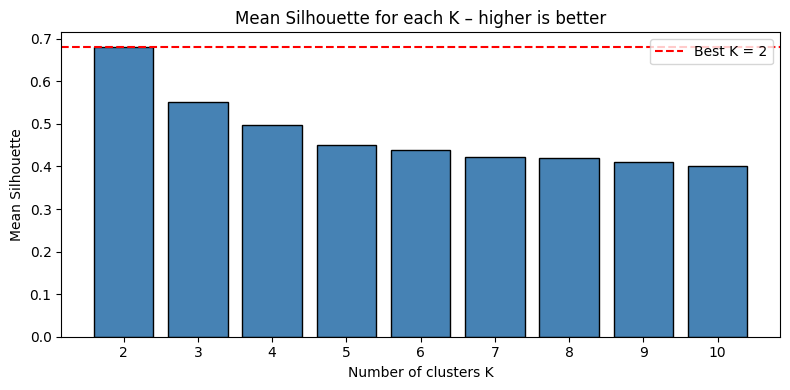

In [12]:
#Here I used AI

# This plot shows WHY the chosen K is the best.
# The highest bar = the winning K.
#
# Note: we need to re-run K-means for each K just for the plot
# because we only saved the best overall result above.

k_values = list(range(2, max_K + 1))
sil_scores = []

print("Computing silhouette for each K (for the plot)...")

for K in k_values:
    best_sil = -1.0
    for run in range(runs_per_K):
        cluster_of_point, points_in_cluster, centroids = kmeans(all_points, K)
        sil = mean_silhouette(all_points, cluster_of_point, points_in_cluster)
        if sil > best_sil:
            best_sil = sil
    sil_scores.append(best_sil)
    print(f"  K = {K}  →  silhouette = {best_sil:.4f}")

# Draw the bar chart
plt.figure(figsize=(8, 4))
plt.bar(k_values, sil_scores, color="steelblue", edgecolor="black")
plt.xlabel("Number of clusters K")
plt.ylabel("Mean Silhouette")
plt.title("Mean Silhouette for each K – higher is better")
plt.xticks(k_values)
plt.axhline(y=max(sil_scores), color="red", linestyle="--",
            label=f"Best K = {k_values[sil_scores.index(max(sil_scores))]}")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Cluster the dataset in the two scenarios described in Section 4:

In [29]:
# PCS and projection
# Steps:
#   1. Compute the mean of each column manually
#   2. Center the data (subtract the mean)
#   3. Build the covariance matrix with for loops
#   4. Find eigenvectors with np.linalg.eig (only numpy allowed here)
#   5. Sort by biggest eigenvalue first

def pca(points):
    N = len(points)
    D = len(points[0])


    mean = [0.0] * D
    for i in range(N):
        for d in range(D):
            mean[d] += points[i][d]
    for d in range(D):
        mean[d] /= N


    centered = []
    for i in range(N):
        row = [points[i][d] - mean[d] for d in range(D)]
        centered.append(row)
    centered = np.array(centered)

    cov_matrix = [[0.0] * D for _ in range(D)]
    for i in range(N):
        for a in range(D):
            for b in range(D):
                cov_matrix[a][b] += centered[i][a] * centered[i][b]
    for a in range(D):
        for b in range(D):
            cov_matrix[a][b] /= N
    cov_matrix = np.array(cov_matrix)

    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    eigenvalues = eigenvalues.real
    eigenvectors = eigenvectors.real

    sorted_eigenvalues = []
    sorted_eigenvectors = []

    ev_list = list(enumerate(eigenvalues))
    for _ in range(D):
        best_idx = 0
        best_val = ev_list[0][1]
        for j in range(1, len(ev_list)):
            if ev_list[j][1] > best_val:
                best_val = ev_list[j][1]
                best_idx = j
        original_index = ev_list[best_idx][0]
        sorted_eigenvalues.append(best_val)
        sorted_eigenvectors.append(eigenvectors[:, original_index])
        ev_list.pop(best_idx)

    return sorted_eigenvalues, sorted_eigenvectors

# to 2 Dimendions
def project_to_2D(points, eigenvectors):
    pc1 = eigenvectors[0]
    pc2 = eigenvectors[1]

    N = len(points)
    projected = []

    for i in range(N):
        coord1 = 0
        coord2 = 0
        for d in range(len(points[i])):
            coord1 += points[i][d] * pc1[d]
            coord2 += points[i][d] * pc2[d]
        projected.append([coord1, coord2])

    return np.array(projected)

In [30]:
# Scenario A
print("Scenario A: Cluster→ Project to 2D")

# Cluter
K = best_K
cluster_of_point_A, points_in_cluster_A, centroids_A = kmeans(all_points, K)
sil_A = mean_silhouette(all_points, cluster_of_point_A, points_in_cluster_A)

print(f"K = {K},  mean silhouette = {sil_A:.4f}")
for k in range(K):
    print(f"  Cluster {k}: {len(points_in_cluster_A[k])} flowers")

# project
eigenvalues_A, eigenvectors_A = pca(all_points)
points_2D_A = project_to_2D(all_points, eigenvectors_A)

print("Projection to 2D done (for display only).")

Scenario A: Cluster→ Project to 2D
  K-means converged after 6 iterations.
K = 2,  mean silhouette = 0.6810
  Cluster 0: 53 flowers
  Cluster 1: 97 flowers
Projection to 2D done (for display only).


In [31]:
#Scenario B – project to 2D first, then cluster ──
print("=== Scenario B: Reduce to 2D → Cluster (2D) ===")

# Project
eigenvalues_B, eigenvectors_B = pca(all_points)
points_2D_B = project_to_2D(all_points, eigenvectors_B)

#Cluster
K = best_K
cluster_of_point_B, points_in_cluster_B, centroids_B = kmeans(points_2D_B, K)
sil_B = mean_silhouette(points_2D_B, cluster_of_point_B, points_in_cluster_B)

print(f"K = {K},  mean silhouette = {sil_B:.4f}")
for k in range(K):
    print(f"  Cluster {k}: {len(points_in_cluster_B[k])} flowers")

=== Scenario B: Reduce to 2D → Cluster (2D) ===
  K-means converged after 5 iterations.
K = 2,  mean silhouette = 0.7057
  Cluster 0: 53 flowers
  Cluster 1: 97 flowers


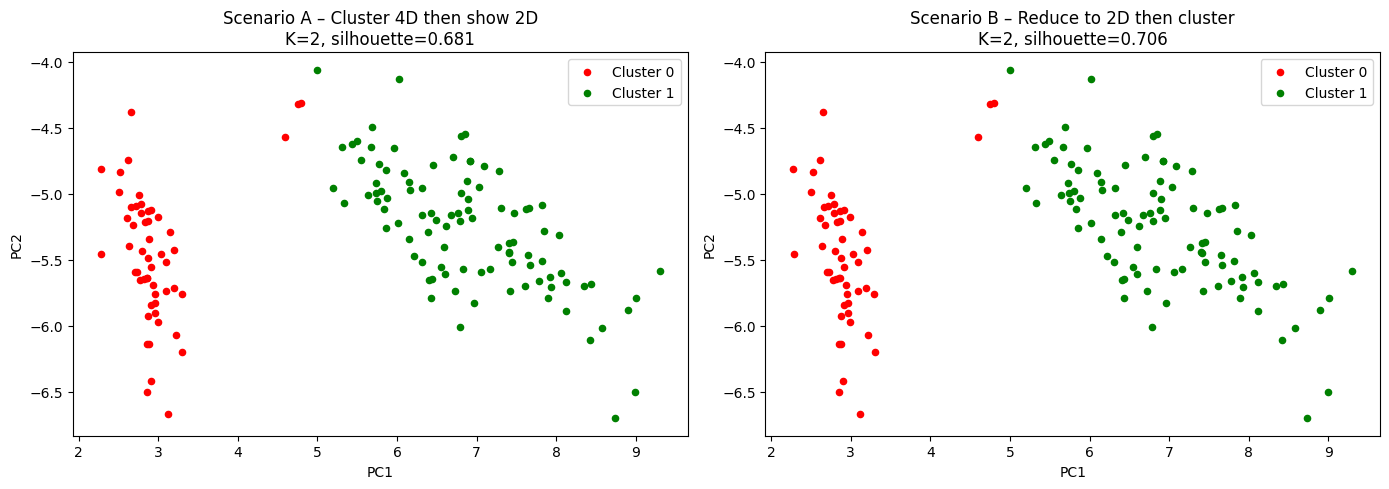

In [32]:
# here I used AI
# ── Cell 17: Plot both scenarios side by side ─────────────────

colors = ["red", "green", "blue", "orange", "purple",
          "brown", "pink", "gray", "cyan", "yellow"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scenario A plot ---
ax = axes[0]
for k in range(best_K):
    x_vals = []
    y_vals = []
    for point_id in points_in_cluster_A[k]:        # <-- fix: was best_points_A
        x_vals.append(points_2D_A[point_id][0])
        y_vals.append(points_2D_A[point_id][1])
    ax.scatter(x_vals, y_vals, color=colors[k], s=20, label=f"Cluster {k}")

ax.set_title(f"Scenario A – Cluster 4D then show 2D\nK=2, silhouette={sil_A:.3f}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

# --- Scenario B plot ---
ax = axes[1]
for k in range(best_K):
    x_vals = []
    y_vals = []
    for point_id in points_in_cluster_B[k]:        # <-- fix: was best_points_B
        x_vals.append(points_2D_B[point_id][0])
        y_vals.append(points_2D_B[point_id][1])
    ax.scatter(x_vals, y_vals, color=colors[k], s=20, label=f"Cluster {k}")

ax.set_title(f"Scenario B – Reduce to 2D then cluster\nK=2, silhouette={sil_B:.3f}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

plt.tight_layout()
plt.show()